# Лабораторна робота №3
**Тема:** Лінійна регресія у Scikit-learn: підготовка даних, навчання, прогнозування та оцінювання якості моделі
**Мета:** Набути практичних навичок розв’язання задачі регресії, побудови конвеєра (Pipeline) та оцінки моделі.
**Студентка:** Чернега Катерина, Група МІТ-31
**Набір даних:** Laptop Prices (Kaggle)
**Цільова змінна:** `Price_euros` (Ціна ноутбука в євро)
**Задача прогнозування:** Визначити орієнтовну вартість ноутбука на основі його технічних характеристик (бренд, тип, оперативна пам'ять, процесор тощо).

In [1]:
#Крок 1: Імпорт бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Задаємо зерно генератора випадкових чисел
SEED = 4

#Крок 2:Завантаження та первинний огляд даних
df = pd.read_csv('laptop_prices.csv')

print("Перші 5 рядків датасету:")
display(df.head())

print("\nФорма таблиці (рядки, стовпці):", df.shape)
print("\nТипи даних:")
print(df.dtypes)

Перші 5 рядків датасету:


,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650



Форма таблиці (рядки, стовпці): (1275, 23)

Типи даних:
Company                  object
Product                  object
TypeName                 object
Inches                  float64
Ram                       int64
OS                       object
Weight                  float64
Price_euros             float64
Screen                   object
ScreenW                   int64
ScreenH                   int64
Touchscreen              object
IPSpanel                 object
RetinaDisplay            object
CPU_company              object
CPU_freq                float64
CPU_model                object
PrimaryStorage            int64
SecondaryStorage          int64
PrimaryStorageType       object
SecondaryStorageType     object
GPU_company              object
GPU_model                object
dtype: object


--- Перевірка на пропуски та дублікати ---
Сума пропусків по стовпцях (топ-5):
 Company     0
Product     0
TypeName    0
Inches      0
Ram         0
dtype: int64

Кількість повних дублікатів: 0
Форма таблиці після видалення дублікатів: (1275, 23)

--- Описова статистика ---


,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


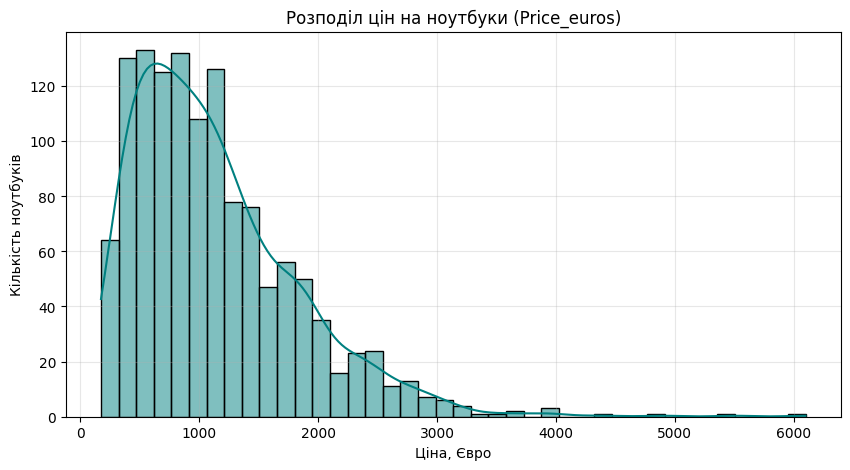

In [2]:
# --- Крок 3: Первинна перевірка даних ---
print("--- Перевірка на пропуски та дублікати ---")
print("Сума пропусків по стовпцях (топ-5):\n", df.isna().sum().sort_values(ascending=False).head())
print("\nКількість повних дублікатів:", df.duplicated().sum())

# Одразу видаляємо дублікати, якщо вони є
df = df.drop_duplicates()
print("Форма таблиці після видалення дублікатів:", df.shape)

print("\n--- Описова статистика ---")
display(df.describe())

# Візуалізація розподілу цільової змінної (Price_euros)
plt.figure(figsize=(10, 5))
sns.histplot(df['Price_euros'], bins=40, kde=True, color='teal')
plt.title("Розподіл цін на ноутбуки (Price_euros)")
plt.xlabel("Ціна, Євро")
plt.ylabel("Кількість ноутбуків")
plt.grid(True, alpha=0.3)
plt.show()

**Висновок до первинного аналізу:**
Датасет містить 1275 записів без повних дублікатів. Розподіл цільової змінної (`Price_euros`) є асиметричним (скошеним вправо), що є типовим для цінових даних: більшість спостережень зосереджена в нижньому та середньому цінових діапазонах, із невеликою кількістю дорогих пристроїв.

In [3]:
from sklearn.model_selection import train_test_split

#Крок 4: Розподіл на X (ознаки) та y (цільова змінна)
y = df['Price_euros']
X = df.drop(columns=['Price_euros'])

#Розбиваємо на навчальну (train) та тестову (test) вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Розмір навчальної вибірки (train): {X_train.shape}")
print(f"Розмір тестової вибірки (test): {X_test.shape}")

#Крок 5: Автоматичне визначення типів ознак
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\nКількість числових ознак: {len(numeric_features)}")
print(f"Кількість категоріальних ознак: {len(categorical_features)}")

Розмір навчальної вибірки (train): (1020, 22)
Розмір тестової вибірки (test): (255, 22)

Кількість числових ознак: 8
Кількість категоріальних ознак: 14


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

#Крок 6: Конвеєр підготовки даних (Pipeline)
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessing = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

#Створюємо дві моделі
dummy_model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", DummyRegressor(strategy="mean")),
])

lr_model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", LinearRegression()),
])

#Крок 7: Навчання моделей
print("Навчаємо моделі на тренувальній вибірці...")
dummy_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
print("Навчання завершено успішно!\n")

#Крок 8: Прогнозування та метрики (на тестовій вибірці)
y_pred_dummy = dummy_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

print("--- Оцінка якості моделей (на тестових даних) ---")

#Оцінка DummyRegressor
mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = mean_squared_error(y_test, y_pred_dummy) ** 0.5
r2_dummy = r2_score(y_test, y_pred_dummy)
print(f"Базова модель (Dummy): MAE = {mae_dummy:.2f} €, RMSE = {rmse_dummy:.2f} €, R² = {r2_dummy:.4f}")

#Оцінка LinearRegression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Лінійна регресія:    MAE = {mae_lr:.2f} €, RMSE = {rmse_lr:.2f} €, R² = {r2_lr:.4f}")

Навчаємо моделі на тренувальній вибірці...
Навчання завершено успішно!

--- Оцінка якості моделей (на тестових даних) ---
Базова модель (Dummy): MAE = 545.29 €, RMSE = 698.04 €, R² = -0.0003
Лінійна регресія:    MAE = 222.41 €, RMSE = 299.69 €, R² = 0.8156


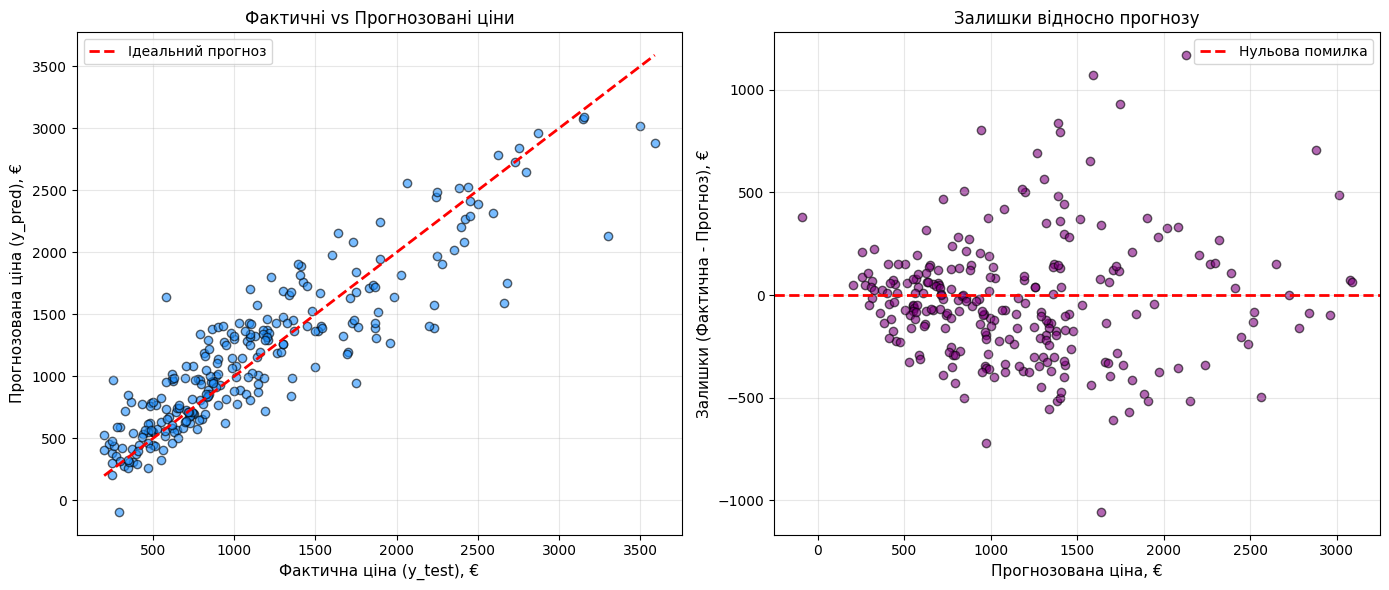

In [5]:
#Крок 9: Візуалізація результатів моделі
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#1.Графік: Фактичні значення проти прогнозованих
axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='dodgerblue', edgecolor='k')
#Додаємо лінію ідеального прогнозу
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ідеальний прогноз')
axes[0].set_title('Фактичні vs Прогнозовані ціни', fontsize=12)
axes[0].set_xlabel('Фактична ціна (y_test), €', fontsize=11)
axes[0].set_ylabel('Прогнозована ціна (y_pred), €', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#2.Графік: Залишки (Residuals) відносно прогнозу
residuals = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals, alpha=0.6, color='purple', edgecolor='k')
#Додаємо нульову лінію (де помилка = 0)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Нульова помилка')
axes[1].set_title('Залишки відносно прогнозу', fontsize=12)
axes[1].set_xlabel('Прогнозована ціна, €', fontsize=11)
axes[1].set_ylabel('Залишки (Фактична - Прогноз), €', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Lab3_residuals.png', dpi=300) #Зберігаємо рисунок за вимогою
plt.show()

**Інтерпретація результатів моделювання:**
1.**Порівняння з базовою моделлю:** Побудована лінійна регресія значно перевершує `DummyRegressor`. MAE зменшилась удвічі (з 545 € до 222 €), а метрика R² зросла з 0 до 0.81, що свідчить про високу пояснювальну здатність моделі.
2.**Аналіз помилок:** На графіку "Фактичні vs Прогнозовані" видно, що точки щільно групуються навколо ідеальної червоної лінії в сегменті до 2000 €. Проте для дорогих преміальних ноутбуків (понад 2500 €) розкид стає значно більшим.
3.**Структура залишків:** Графік залишків має форму "лійки" (гетероскедастичність) - чим дорожчий ноутбук прогнозує модель, тим більшою стає абсолютна похибка. Це означає, що лінійна модель добре вловлює базові тренди ціноутворення, але не здатна ідеально оцінити унікальні характеристики преміальних геймерських чи професійних пристроїв.

In [6]:
#Крок 10: Збереження результатів
print("--- Збереження файлів ---")

#Створюємо таблицю з результатами прогнозів
predictions_df = pd.DataFrame({
    'Actual_Price': y_test,
    'Predicted_Price': y_pred_lr,
    'Error': y_test - y_pred_lr
})
predictions_df.to_csv('test_predictions.csv', index=False)
print("Файл 'test_predictions.csv' збережено.")

#Створюємо таблицю з порівнянням метрик
metrics_df = pd.DataFrame({
    'Model': ['DummyRegressor', 'LinearRegression'],
    'MAE': [mae_dummy, mae_lr],
    'RMSE': [rmse_dummy, rmse_lr],
    'R2': [r2_dummy, r2_lr]
})
metrics_df.to_csv('metrics.csv', index=False)
print("Файл 'metrics.csv' збережено.")

--- Збереження файлів ---
Файл 'test_predictions.csv' збережено.
Файл 'metrics.csv' збережено.


##Загальний висновок
У ході виконання лабораторної роботи було успішно розв'язано задачу регресії на відкритому наборі даних щодо цін на ноутбуки. 
* Було підготовлено дані, виокремлено цільову змінну (`Price_euros`) та розділено вибірку на навчальну й тестову (80/20) без витоку даних.
* Створено `Pipeline` із `ColumnTransformer` для автоматичної обробки числових і категоріальних ознак (One-Hot Encoding).
* Побудована лінійна регресія (`LinearRegression`) показала адекватні результати (R² ≈ 0.81), значно перевершивши базову модель (`DummyRegressor`).
* Модель є корисною для орієнтовної оцінки вартості, проте аналіз залишків вказує на те, що для преміального сегмента пристроїв похибка зростає. Для покращення результатів у майбутньому можна спробувати нелінійні моделі (наприклад, випадковий ліс).